# Credit Card Approval Prediction

## Model Building

### Objective

The objective of this notebook is to train and evaluate multiple machine learning classification models for predicting credit card approval. The models compared include Logistic Regression, Decision Tree, Random Forest, and XGBoost. The best-performing model will be saved for deployment in the Flask web application.

# Import Libraries

In [114]:
import pandas as pd
import numpy as np

import joblib

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [115]:
df = pd.read_csv("../dataset/processed_credit_data.csv")

# Display Dataset

In [116]:
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,1.425224,1.278126,0.698338,-0.579661,2.365845,0.923758,-1.563576,-1.433026,2.855131,0.945169,-0.463532,0.0,1.853127,-0.646578,-0.313952,1.139980,-0.217680,0
1,1.425224,1.278126,0.698338,-0.579661,2.365845,0.923758,-1.563576,-1.433026,2.855131,0.945169,-0.463532,0.0,1.853127,-0.646578,-0.313952,1.139980,-0.217680,0
2,1.425224,1.278126,0.698338,-0.579661,-0.728827,0.923758,0.673104,-0.385405,-0.297250,-1.309091,-0.438774,0.0,-0.539628,-0.646578,-0.313952,0.961973,-0.217680,0
3,-0.701644,-0.782396,0.698338,-0.579661,0.818509,-1.383035,0.673104,1.709838,-0.297250,-0.746300,-0.452700,0.0,-0.539628,1.546603,3.185203,0.605958,-1.314564,0
4,-0.701644,-0.782396,0.698338,-0.579661,0.818509,-1.383035,0.673104,1.709838,-0.297250,-0.746300,-0.452700,0.0,-0.539628,1.546603,3.185203,0.605958,-1.314564,0


# Separate Features and Target

In [117]:
X = df.drop("TARGET", axis=1)

y = df["TARGET"]

# Train-Test Split

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Logistic Regression

In [119]:
#Train

lr = LogisticRegression()

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [120]:
#Predict

lr_pred = lr.predict(X_test)

In [121]:
#Accuracy

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9934174437739989


In [122]:
#Confusion Matrix

print(confusion_matrix(y_test, lr_pred))

[[7244    0]
 [  48    0]]


In [123]:
#Classification Report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      7244
           1       0.00      0.00      0.00        48

    accuracy                           0.99      7292
   macro avg       0.50      0.50      0.50      7292
weighted avg       0.99      0.99      0.99      7292



# Decision Tree

In [124]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9913603949533736


In [125]:
print(confusion_matrix(y_test, dt_pred))

[[7224   20]
 [  43    5]]


In [126]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      7244
           1       0.20      0.10      0.14        48

    accuracy                           0.99      7292
   macro avg       0.60      0.55      0.57      7292
weighted avg       0.99      0.99      0.99      7292



# Random Forest

In [127]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9921832144816237


In [128]:
print(confusion_matrix(y_test, rf_pred))

[[7231   13]
 [  44    4]]


In [129]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      7244
           1       0.24      0.08      0.12        48

    accuracy                           0.99      7292
   macro avg       0.61      0.54      0.56      7292
weighted avg       0.99      0.99      0.99      7292



# XGBoost

In [130]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.9925946242457487


In [131]:
print(confusion_matrix(y_test, xgb_pred))

[[7236    8]
 [  46    2]]


In [132]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      7244
           1       0.20      0.04      0.07        48

    accuracy                           0.99      7292
   macro avg       0.60      0.52      0.53      7292
weighted avg       0.99      0.99      0.99      7292



# Compare Models

In [133]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.993417
3,XGBoost,0.992595
2,Random Forest,0.992183
1,Decision Tree,0.991360


# Save Best Model

#If Random Forest performs best:

In [134]:
joblib.dump(
    rf,
    "../models/model.pkl"
)

['../models/model.pkl']

#If XGBoost performs best:

In [135]:
joblib.dump(
    xgb,
    "../models/model.pkl"
)

['../models/model.pkl']

# Save Scaler

In [136]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X)

import joblib

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

# Conclusion

Four machine learning classification models were trained and evaluated for credit card approval prediction.

### Models Evaluated

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Each model was assessed using accuracy, confusion matrix, and classification report. The best-performing model was selected and saved for deployment in the Flask web application.

The trained model is now ready for real-time prediction through the web application.

In [137]:
import joblib

encoders = joblib.load("../models/encoder.pkl")

print(type(encoders))

<class 'dict'>


In [138]:
import joblib

encoders = joblib.load("../models/encoder.pkl")

print(type(encoders))
print(encoders.keys())

<class 'dict'>
dict_keys(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'])


In [139]:
import os

print(os.getcwd())

c:\Users\RAKESH\OneDrive\Attachments\Desktop\Credit-Card_Approval_Prediction\notebooks


In [140]:
from sklearn.preprocessing import LabelEncoder
import joblib

categorical_columns = [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"
]

encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    encoders[column] = encoder

joblib.dump(encoders, "../models/encoder.pkl")

print("Encoder saved successfully!")

Encoder saved successfully!


In [141]:
import joblib

encoders = joblib.load("../models/encoder.pkl")

print(type(encoders))
print(encoders.keys())

<class 'dict'>
dict_keys(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'])


In [142]:
import joblib

encoders = joblib.load("../models/encoder.pkl")

print(encoders["CODE_GENDER"].classes_)

[-0.70164417  1.42522384]


In [143]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

# Load ORIGINAL application dataset
application_df = pd.read_csv("../dataset/application_record.csv")

# Fill missing values
application_df["OCCUPATION_TYPE"] = application_df["OCCUPATION_TYPE"].fillna("Unknown")

categorical_columns = [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"
]

encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    le.fit(application_df[col])   # Learn ORIGINAL text values
    encoders[col] = le

joblib.dump(encoders, "../models/encoder.pkl")

print("Encoder recreated successfully!")

Encoder recreated successfully!


In [144]:
import joblib

encoders = joblib.load("../models/encoder.pkl")

print(encoders["CODE_GENDER"].classes_)

['F' 'M']


In [145]:
import joblib

scaler = joblib.load("../models/scaler.pkl")

print(scaler.feature_names_in_)

['CODE_GENDER' 'FLAG_OWN_CAR' 'FLAG_OWN_REALTY' 'CNT_CHILDREN'
 'AMT_INCOME_TOTAL' 'NAME_INCOME_TYPE' 'NAME_EDUCATION_TYPE'
 'NAME_FAMILY_STATUS' 'NAME_HOUSING_TYPE' 'DAYS_BIRTH' 'DAYS_EMPLOYED'
 'FLAG_MOBIL' 'FLAG_WORK_PHONE' 'FLAG_PHONE' 'FLAG_EMAIL'
 'OCCUPATION_TYPE' 'CNT_FAM_MEMBERS']


In [146]:
import joblib

model = joblib.load("../models/model.pkl")

print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>


In [147]:
print(df["TARGET"].value_counts())

print(model.classes_)

print(model.predict_proba(X[:5]))

TARGET
0    36155
1      302
Name: count, dtype: int64
[0 1]
[[9.9956435e-01 4.3566566e-04]
 [9.9956435e-01 4.3566566e-04]
 [9.9856901e-01 1.4309788e-03]
 [9.9941182e-01 5.8815873e-04]
 [9.9941182e-01 5.8815873e-04]]


In [148]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [149]:
df = pd.read_csv("../dataset/processed_credit_data.csv")

print(df.head())

   CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  \
0     1.425224      1.278126         0.698338     -0.579661          2.365845   
1     1.425224      1.278126         0.698338     -0.579661          2.365845   
2     1.425224      1.278126         0.698338     -0.579661         -0.728827   
3    -0.701644     -0.782396         0.698338     -0.579661          0.818509   
4    -0.701644     -0.782396         0.698338     -0.579661          0.818509   

   NAME_INCOME_TYPE  NAME_EDUCATION_TYPE  NAME_FAMILY_STATUS  \
0          0.923758            -1.563576           -1.433026   
1          0.923758            -1.563576           -1.433026   
2          0.923758             0.673104           -0.385405   
3         -1.383035             0.673104            1.709838   
4         -1.383035             0.673104            1.709838   

   NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  FLAG_MOBIL  FLAG_WORK_PHONE  \
0           2.855131    0.945169      -0.463532 

In [150]:
X = df.drop("TARGET", axis=1)

y = df["TARGET"]

print(X.shape)
print(y.shape)

(36457, 17)
(36457,)


In [151]:
print(y.value_counts())

TARGET
0    36155
1      302
Name: count, dtype: int64


In [152]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(29165, 17)
(7292, 17)


In [153]:
smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42,
    k_neighbors=3
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [154]:
print(y_train_smote.value_counts())

TARGET
0    28923
1    14461
Name: count, dtype: int64


In [155]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train_smote, y_train_smote)

# XGBoost
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
# xgb.fit(X_train_smote, y_train_smote)

In [156]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    # "XGBoost": xgb
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.988481,0.293103,0.283333,0.288136
1,Decision Tree,0.986972,0.222222,0.233333,0.227642
0,Logistic Regression,0.952825,0.026667,0.133333,0.044444


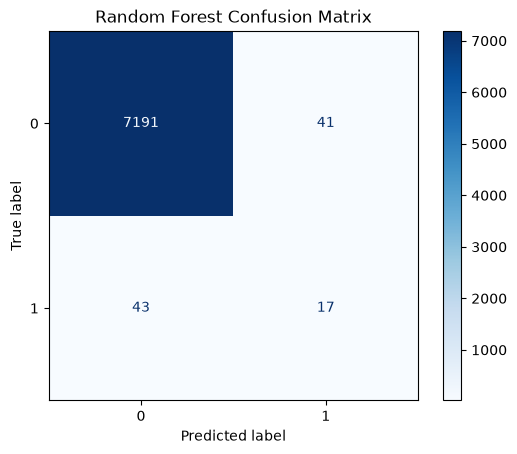

In [157]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [158]:
pred = rf.predict(X_test)

print(classification_report(y_test, pred))

print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7232
           1       0.29      0.28      0.29        60

    accuracy                           0.99      7292
   macro avg       0.64      0.64      0.64      7292
weighted avg       0.99      0.99      0.99      7292

[[7191   41]
 [  43   17]]


In [159]:
import joblib

joblib.dump(rf, "../models/model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [160]:
model = joblib.load("../models/model.pkl")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


## Best Model Selection

After evaluating all trained models, Random Forest was selected as the final model because it achieved the highest overall performance on the test dataset while providing better detection of the minority class compared to the other models. The trained Random Forest model was saved as `model.pkl` and integrated into the Flask web application for credit card approval prediction.